# Problem Title - Scratch Mode
Issue: #2

## 1. Setup and Imports
Use only NumPy and pandas for scratch work; do not use ML libraries unless the issue explicitly allows them.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


np.random.seed(42)

## 2. Load and Inspect Data
Load dataset.csv and validate shape, columns, and missing values before training.

In [3]:
df = pd.read_csv("../dataset.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  quality_binary        6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [4]:
df.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,quality_binary
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.196552
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.397421
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,0.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,0.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,0.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


In [5]:
df["quality_binary"].value_counts()

quality_binary
0    5220
1    1277
Name: count, dtype: int64

In [6]:
df["quality"].value_counts()

quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64

In [7]:
df = df.drop("quality", axis=1) #no need for this

In [8]:
df.corr()["quality_binary"].sort_values(ascending=False)

quality_binary          1.000000
alcohol                 0.390486
citric_acid             0.054444
sulphates               0.033971
pH                      0.028149
free_sulfur_dioxide     0.014767
fixed_acidity          -0.049447
total_sulfur_dioxide   -0.051226
residual_sugar         -0.063992
volatile_acidity       -0.151714
chlorides              -0.161781
density                -0.275441
Name: quality_binary, dtype: float64

In [9]:
shape = df.shape
(shape[0], shape[1])


(6497, 12)

## 3. Preprocessing
Prepare features and target explicitly, including any normalization or encoding steps.

In [10]:
df = df.sample(frac=1).reset_index(drop=True)

df['alcohol_bin'] = pd.qcut(df['alcohol'], q=5, labels=False)
df['stratify_key'] = df['quality_binary'].astype(str) + "_" + df['alcohol_bin'].astype(str)

train_df = df.groupby('stratify_key', group_keys=False).apply(
    lambda x: x.sample(frac=0.80)
)

test_df = df.drop(train_df.index)

columns_to_drop = ['alcohol_bin', 'stratify_key']
train_df = train_df.drop(columns=columns_to_drop, errors="ignore")
test_df = test_df.drop(columns=columns_to_drop, errors="ignore")

In [11]:
features = [col for col in train_df.columns if col != 'quality_binary']

train_mean = train_df[features].mean()
train_std = train_df[features].std()

train_df[features] = (train_df[features] - train_mean) / train_std
test_df[features] = (test_df[features] - train_mean) / train_std

In [12]:
train_x = train_df.drop(columns="quality_binary")
train_y = train_df["quality_binary"]

In [13]:
test_x = test_df.drop(columns="quality_binary")
test_y = test_df["quality_binary"]

In [14]:
shape = train_x.shape
(shape[0], shape[1])

(5198, 11)

In [15]:
X_test_T = test_x.T
Y_test_2D = test_y.to_numpy().reshape(1, -1)
Y_train_2D = train_y.to_numpy().reshape(1, -1)

## 4. Algorithm Implementation
Implement core model logic from scratch and keep helper functions readable and testable.

In [16]:
import numpy as np

def sigmoid(Z):
    
    A = 1/(1+np.exp(-Z))
    cache = Z
    
    return A, cache

def relu(Z):
  
    A = np.maximum(0,Z)
    
    assert(A.shape == Z.shape)
    
    cache = Z 
    return A, cache


def relu_backward(dA, cache):
    
    Z = cache
    dZ = np.array(dA, copy=True) 
    
    dZ[Z <= 0] = 0
    
    assert (dZ.shape == Z.shape)
    
    return dZ

def sigmoid_backward(dA, cache):
    
    Z = cache
    
    s = 1/(1+np.exp(-Z))
    dZ = dA * s * (1-s)
    
    assert (dZ.shape == Z.shape)
    
    return dZ



### 2 - layer Neural Network

the model's structure is (LINER -> RELU) --> (LINER -> SIGMOID)

In [17]:
def initialize_parameters(n_x, n_h, n_y):
   
    np.random.seed(1)
    #He Initialization for the ReLU layer
    W1 = np.random.randn(n_h,n_x) * np.sqrt(2/n_x)
    b1 = np.zeros((n_h,1))
    # 2. Xavier/Glorot Initialization for the Sigmoid layer
    W2 = np.random.randn(n_y,n_h) * np.sqrt(1/n_h)
    b2 = np.zeros((n_y,1))
    
    assert(W1.shape == (n_h, n_x))
    assert(b1.shape == (n_h, 1))
    assert(W2.shape == (n_y, n_h))
    assert(b2.shape == (n_y, 1))
    
    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}
    
    return parameters    

In [18]:
def linear_forward(A, W, b):
   
    Z = np.dot(W,A) + b
    
    assert(Z.shape == (W.shape[0], A.shape[1]))
    cache = (A, W, b)
    
    return Z, cache

In [19]:
def linear_activation_forward(A_prev, W, b, activation):
    
    if activation == "sigmoid":
      
        Z, linear_cache = linear_forward(A_prev, W, b) 
        A, activation_cache = sigmoid(Z)
    
    elif activation == "relu":

        Z, linear_cache = linear_forward(A_prev, W, b) 
        A, activation_cache = relu(Z)
    
    assert (A.shape == (W.shape[0], A_prev.shape[1]))
    cache = (linear_cache, activation_cache)

    return A, cache

In [43]:
def compute_cost(AL, Y):
   
    m = Y.shape[1]
    AL = np.clip(AL, 1e-15, 1 - 1e-15)
    cost = (-1/m) * (np.dot(Y, np.log(AL).T) + np.dot((1-Y), np.log(1-AL).T))
   
    cost = np.squeeze(cost)      
    assert(cost.shape == ())
    
    return cost

In [21]:
def linear_backward(dZ, cache):
   
    A_prev, W, b = cache
    m = A_prev.shape[1]

    dW = (1/m) * np.dot(dZ, A_prev.T)
    db = (1/m) * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = np.dot(W.T,dZ)
    
    assert (dA_prev.shape == A_prev.shape)
    assert (dW.shape == W.shape)
    assert (db.shape == b.shape)
    
    return dA_prev, dW, db

In [22]:
def linear_activation_backward(dA, cache, activation):
   
    linear_cache, activation_cache = cache
    
    if activation == "relu":
        dZ = relu_backward(dA, activation_cache)
        
    elif activation == "sigmoid":
        dZ = sigmoid_backward(dA, activation_cache)
    
    dA_prev, dW, db = linear_backward(dZ, linear_cache)
    
    return dA_prev, dW, db

In [23]:
def update_parameters(parameters, grads, learning_rate):
    
    
    L = len(parameters) // 2

    for l in range(L):
        parameters["W" + str(l+1)] = parameters["W" + str(l+1)] - learning_rate * grads["dW" + str(l+1)]
        parameters["b" + str(l+1)] = parameters["b" + str(l+1)] - learning_rate * grads["db" + str(l+1)]

    return parameters

In [24]:
def initialize_adam(parameters):
    L = len(parameters) // 2 
    v = {}
    s = {}
    
    for l in range(L):
        v["dW" + str(l+1)] = np.zeros_like(parameters["W" + str(l+1)])
        v["db" + str(l+1)] = np.zeros_like(parameters["b" + str(l+1)])
        s["dW" + str(l+1)] = np.zeros_like(parameters["W" + str(l+1)])
        s["db" + str(l+1)] = np.zeros_like(parameters["b" + str(l+1)])
    
    return v, s

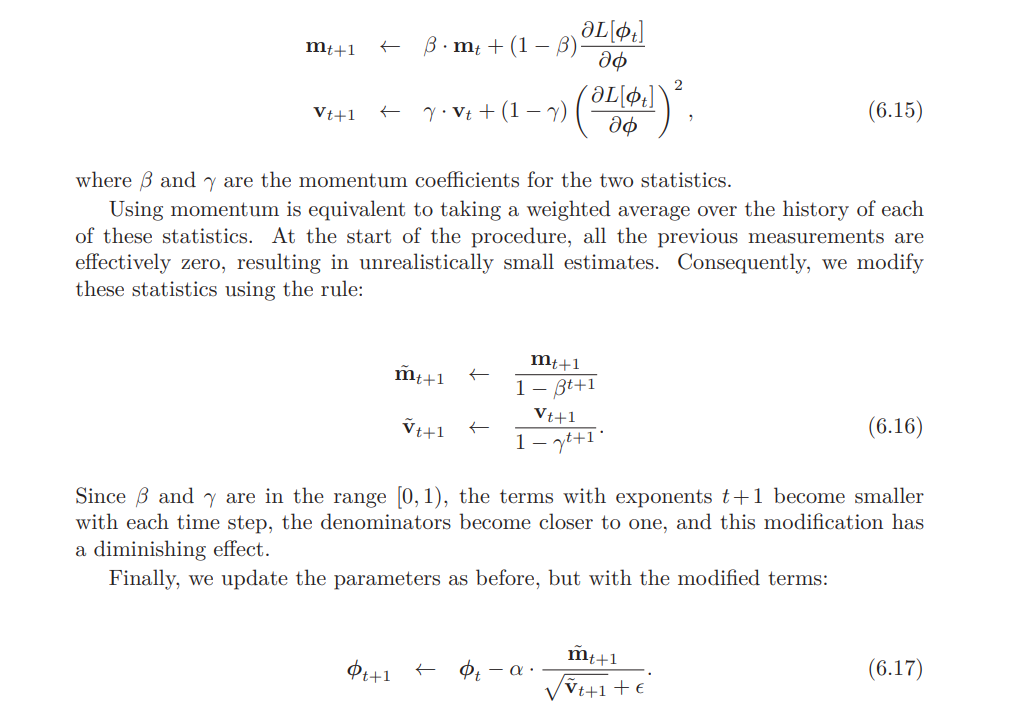

In [26]:
def update_parameters_with_adam(parameters, grads, v, s, t, learning_rate=0.01, beta1=0.9, beta2=0.99, epsilon=1e-8):
    L = len(parameters) // 2                 
    v_corrected = {}                         
    s_corrected = {}                         
    
    for l in range(L):
        # Moving average of the gradients (Momentum)
        v["dW" + str(l+1)] = beta1 * v["dW" + str(l+1)] + (1 - beta1) * grads["dW" + str(l+1)]
        v["db" + str(l+1)] = beta1 * v["db" + str(l+1)] + (1 - beta1) * grads["db" + str(l+1)]
        
        # Bias correction for v
        v_corrected["dW" + str(l+1)] = v["dW" + str(l+1)] / (1 - beta1**t)
        v_corrected["db" + str(l+1)] = v["db" + str(l+1)] / (1 - beta1**t)

        # Moving average of the squared gradients (RMSprop)
        s["dW" + str(l+1)] = beta2 * s["dW" + str(l+1)] + (1 - beta2) * (grads["dW" + str(l+1)]**2)
        s["db" + str(l+1)] = beta2 * s["db" + str(l+1)] + (1 - beta2) * (grads["db" + str(l+1)]**2)
        
        # Bias correction for s
        s_corrected["dW" + str(l+1)] = s["dW" + str(l+1)] / (1 - beta2**t)
        s_corrected["db" + str(l+1)] = s["db" + str(l+1)] / (1 - beta2**t)

        # Update the actual parameters using the Adam formula
        parameters["W" + str(l+1)] = parameters["W" + str(l+1)] - learning_rate * (v_corrected["dW" + str(l+1)] / (np.sqrt(s_corrected["dW" + str(l+1)]) + epsilon))
        parameters["b" + str(l+1)] = parameters["b" + str(l+1)] - learning_rate * (v_corrected["db" + str(l+1)] / (np.sqrt(s_corrected["db" + str(l+1)]) + epsilon))

    return parameters, v, s

## since adam is built for stochastic settings so the trajectory is noisy

i'll be using batch size of 2^6

In [25]:
import math

def random_mini_batches(X, Y, mini_batch_size=128, seed=0):
    """
    Creates a list of random minibatches from (X, Y).
    """
    np.random.seed(seed)
    m = X.shape[1]
    mini_batches = []
        
    permutation = list(np.random.permutation(m))
    shuffled_X = X[:, permutation]
    shuffled_Y = Y[:, permutation].reshape((1, m))

    num_complete_minibatches = math.floor(m / mini_batch_size)
    
    for k in range(0, num_complete_minibatches):
        mini_batch_X = shuffled_X[:, k * mini_batch_size : (k + 1) * mini_batch_size]
        mini_batch_Y = shuffled_Y[:, k * mini_batch_size : (k + 1) * mini_batch_size]
        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append(mini_batch)
    
    if m % mini_batch_size != 0:
        mini_batch_X = shuffled_X[:, num_complete_minibatches * mini_batch_size : ]
        mini_batch_Y = shuffled_Y[:, num_complete_minibatches * mini_batch_size : ]
        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append(mini_batch)
    
    return mini_batches

In [27]:
n_x = 11
n_h = 100
n_y = 1
layers_dims = (n_x, n_h, n_y)

In [34]:
def model(X_train, Y_train, X_test, Y_test, layers_dims, learning_rate=0.01, num_epochs=1000, mini_batch_size=64, print_cost=False):
    
    np.random.seed(1)
    grads = {}
    costs_train = []                           
    costs_test = []                           
    (n_x, n_h, n_y) = layers_dims

    parameters = initialize_parameters(n_x, n_h, n_y)
    
    seed = 10 
    
    for epoch in range(num_epochs):
        
        epoch_cost = 0.
        m = X_train.shape[1]
        
        seed += 1 
        minibatches = random_mini_batches(X_train, Y_train, mini_batch_size, seed)
        num_minibatches = len(minibatches)

        v, s = initialize_adam(parameters)
        t=0

        for minibatch in minibatches:
            (minibatch_X, minibatch_Y) = minibatch
            
            A1, cache1 = linear_activation_forward(minibatch_X, parameters["W1"], parameters["b1"], activation="relu")
            A2, cache2 = linear_activation_forward(A1, parameters["W2"], parameters["b2"], activation="sigmoid")
            
            batch_cost = compute_cost(A2, minibatch_Y)
            epoch_cost += batch_cost / num_minibatches
            
            A2_safe = np.clip(A2, 1e-15, 1 - 1e-15)
            dA2 = - (np.divide(minibatch_Y, A2_safe) - np.divide(1 - minibatch_Y, 1 - A2_safe))
            
            dA1, dW2, db2 = linear_activation_backward(dA2, cache2, activation="sigmoid")
            dA0, dW1, db1 = linear_activation_backward(dA1, cache1, activation="relu")
            
            grads['dW1'] = dW1
            grads['db1'] = db1
            grads['dW2'] = dW2
            grads['db2'] = db2
            
            t += 1 # step counter

            parameters, v, s = update_parameters_with_adam(
                parameters, grads, v, s, t, learning_rate, beta1=0.9, beta2=0.99, epsilon=1e-8 
            )

        if epoch % 50 == 0:
            costs_train.append(epoch_cost)
            
            A1_test, _ = linear_activation_forward(X_test, parameters["W1"], parameters["b1"], activation="relu")
            A2_test, _ = linear_activation_forward(A1_test, parameters["W2"], parameters["b2"], activation="sigmoid")
            test_cost = compute_cost(A2_test, Y_test)
            costs_test.append(test_cost)
            
            if print_cost:
                print(f"Epoch {epoch:4d} | Train Cost: {epoch_cost:.5f} | Test Cost: {test_cost:.5f}")
                
    import matplotlib.pyplot as plt
    plt.plot(np.squeeze(costs_train), label='Train Cost', color='blue')
    plt.plot(np.squeeze(costs_test), label='Test Cost', color='red', linestyle='--')
    plt.ylabel('Cost')
    plt.xlabel('Epochs (per 50)')
    plt.title(f"Learning rate = {learning_rate} | Batch Size = {mini_batch_size}")
    plt.legend(loc='upper right')
    plt.show()
    
    return parameters

In [29]:
def predict(X, y, parameters):
    
    m = X.shape[1]
    
    A1, _ = linear_activation_forward(X, parameters["W1"], parameters["b1"], activation="relu")
    probas, _ = linear_activation_forward(A1, parameters["W2"], parameters["b2"], activation="sigmoid")
    
   
    p = (probas > 0.5).astype(int)
    

    accuracy = np.mean(p == y) * 100
    print(f"Accuracy: {accuracy:.2f}%")
        
    return p

## 5. Training
Train your scratch implementation and track learning behavior across iterations.

Epoch    0 | Train Cost: 0.46310 | Test Cost: 0.40991
Epoch   50 | Train Cost: 0.32614 | Test Cost: 0.36035
Epoch  100 | Train Cost: 0.30376 | Test Cost: 0.35158
Epoch  150 | Train Cost: 0.28462 | Test Cost: 0.35114
Epoch  200 | Train Cost: 0.26844 | Test Cost: 0.35459
Epoch  250 | Train Cost: 0.25729 | Test Cost: 0.35856
Epoch  300 | Train Cost: 0.24579 | Test Cost: 0.36424
Epoch  350 | Train Cost: 0.23463 | Test Cost: 0.37646
Epoch  400 | Train Cost: 0.22679 | Test Cost: 0.37873
Epoch  450 | Train Cost: 0.21893 | Test Cost: 0.37746
Epoch  500 | Train Cost: 0.21475 | Test Cost: 0.38361
Epoch  550 | Train Cost: 0.20541 | Test Cost: 0.39076
Epoch  600 | Train Cost: 0.20182 | Test Cost: 0.40007
Epoch  650 | Train Cost: 0.19422 | Test Cost: 0.40337
Epoch  700 | Train Cost: 0.19056 | Test Cost: 0.41004
Epoch  750 | Train Cost: 0.18846 | Test Cost: 0.42376
Epoch  800 | Train Cost: 0.18214 | Test Cost: 0.42979
Epoch  850 | Train Cost: 0.17733 | Test Cost: 0.43044
Epoch  900 | Train Cost: 0.1

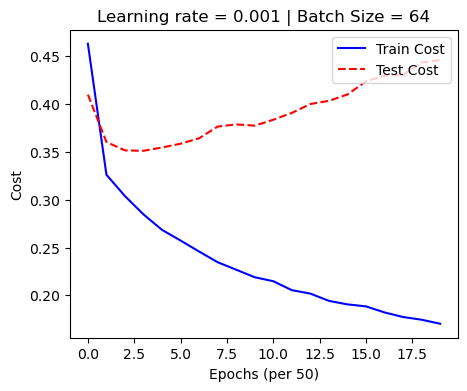

In [40]:
X_train_np = train_x.T.to_numpy()
X_test_np = test_x.T.to_numpy()

Y_train_2D = train_y.to_numpy().reshape(1, -1)
Y_test_2D = test_y.to_numpy().reshape(1, -1)

parameters = model(
    X_train=X_train_np, 
    Y_train=Y_train_2D, 
    X_test=X_test_np, 
    Y_test=Y_test_2D, 
    layers_dims=(n_x, n_h, n_y), 
    learning_rate=0.001,       
    num_epochs=1000, 
    mini_batch_size=64, 
    print_cost=True
)

## 6. Evaluation
Report the correct metric clearly and compare achieved value with target threshold.

In [41]:
train_predictions = predict(train_x.T, Y_train_2D, parameters)
test_predictions = predict(X_test_T, Y_test_2D, parameters)

Accuracy: 93.31%
Accuracy: 84.83%


## 7. Summary
Answer only these scratch-training questions:
1. Which core steps did you implement from scratch (math + code)?
2. How did your training behavior change over iterations (loss/metric trend), and what explains it?
3. What have you learned from implementing and evaluating this model from scratch in this notebook?

### ANS

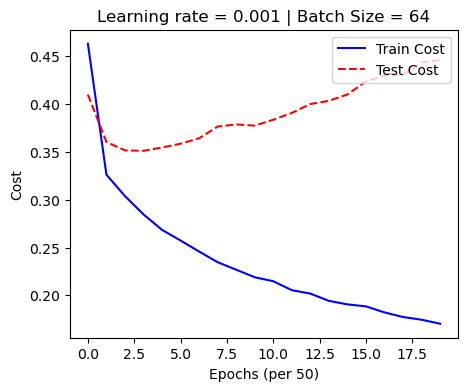<br>
Accuracy: 93.31%
Accuracy: 84.83%<br>
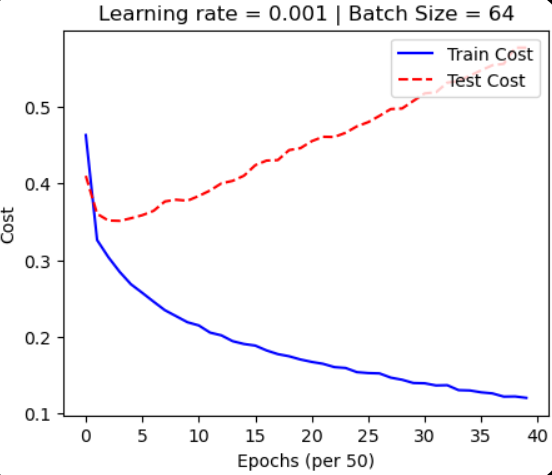<br>
Accuracy: 95.79%
Accuracy: 85.30%

# as we can see the test loss has increased but accuracy has also increased, this is beacuse of how cross-entropry loss works. model is getting more confident about it's predictions i.e. it's overfitting the data. this can be solved by using dropout or L2 to make sure the the wieghts remain small 

# bellow this is just a experiment to see the double descent in work

Training model with n_h = 2...


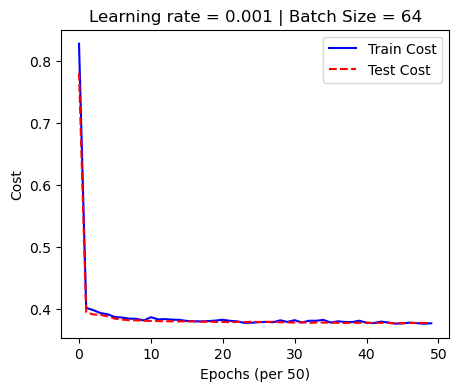

Accuracy: 81.69%
Accuracy: 82.37%
Result -> Train Error: 18.31% | Test Error: 17.63%

Training model with n_h = 5...


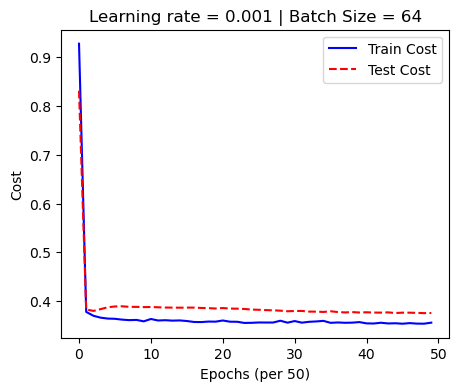

Accuracy: 83.36%
Accuracy: 82.37%
Result -> Train Error: 16.64% | Test Error: 17.63%

Training model with n_h = 10...


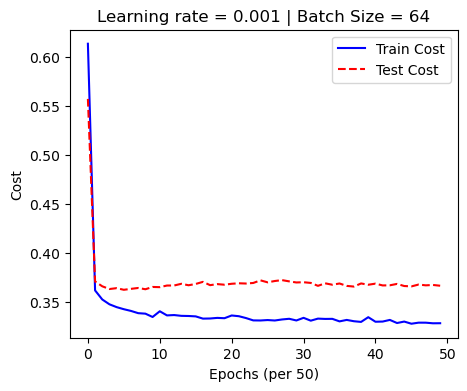

Accuracy: 84.21%
Accuracy: 83.91%
Result -> Train Error: 15.79% | Test Error: 16.09%

Training model with n_h = 20...


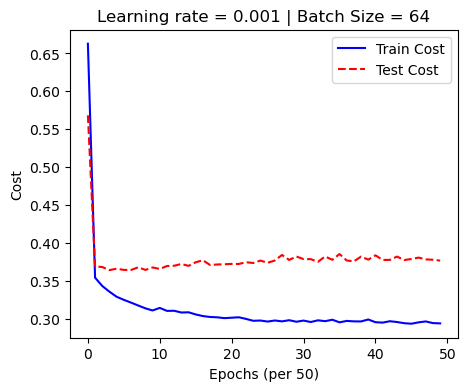

Accuracy: 86.55%
Accuracy: 83.06%
Result -> Train Error: 13.45% | Test Error: 16.94%

Training model with n_h = 40...


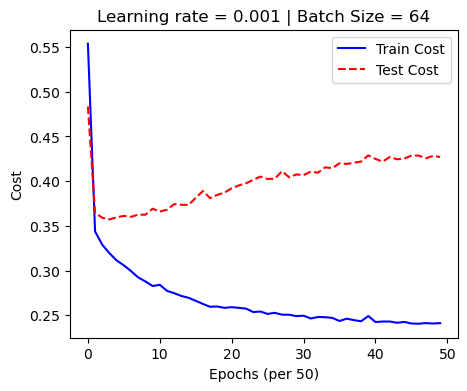

Accuracy: 89.80%
Accuracy: 83.06%
Result -> Train Error: 10.20% | Test Error: 16.94%

Training model with n_h = 80...


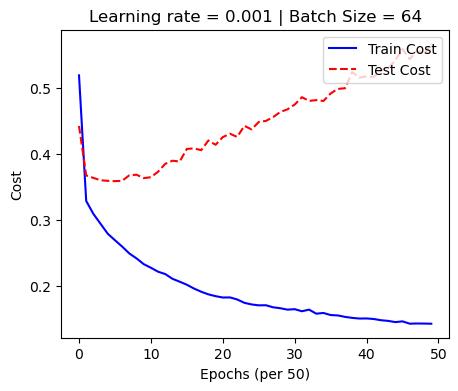

Accuracy: 94.96%
Accuracy: 84.45%
Result -> Train Error: 5.04% | Test Error: 15.55%

Training model with n_h = 150...


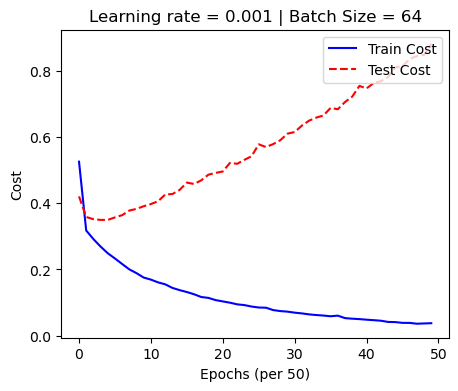

Accuracy: 99.73%
Accuracy: 84.99%
Result -> Train Error: 0.27% | Test Error: 15.01%

Training model with n_h = 300...


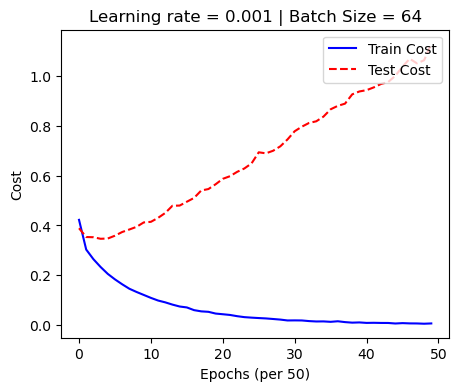

Accuracy: 99.96%
Accuracy: 85.91%
Result -> Train Error: 0.04% | Test Error: 14.09%

Training model with n_h = 500...


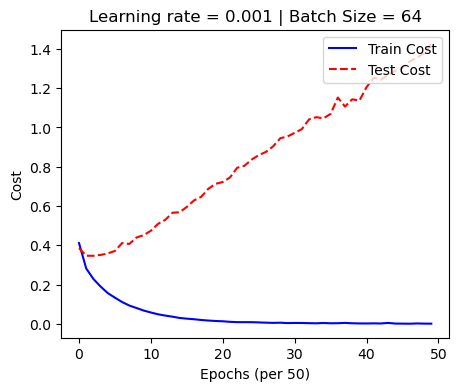

Accuracy: 99.96%
Accuracy: 86.84%
Result -> Train Error: 0.04% | Test Error: 13.16%

Training model with n_h = 1000...


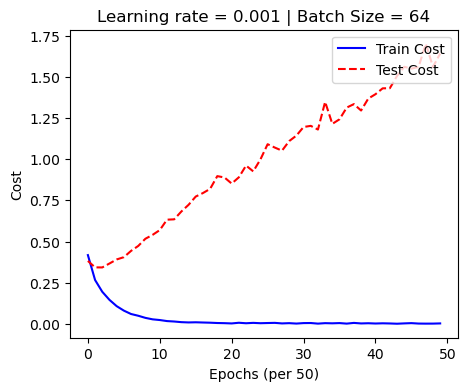

Accuracy: 99.98%
Accuracy: 86.91%
Result -> Train Error: 0.02% | Test Error: 13.09%

Training model with n_h = 1500...


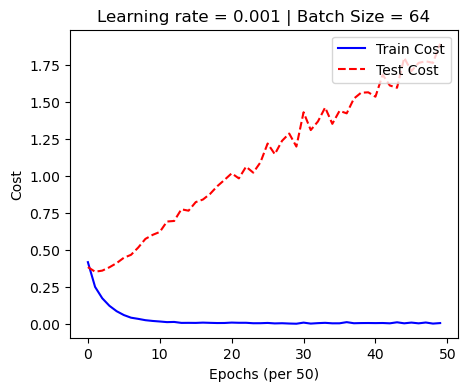

Accuracy: 100.00%
Accuracy: 87.53%
Result -> Train Error: 0.00% | Test Error: 12.47%

Training model with n_h = 2000...


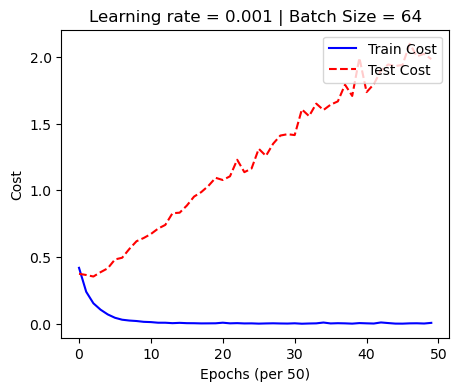

Accuracy: 99.94%
Accuracy: 86.91%
Result -> Train Error: 0.06% | Test Error: 13.09%

Training model with n_h = 2500...


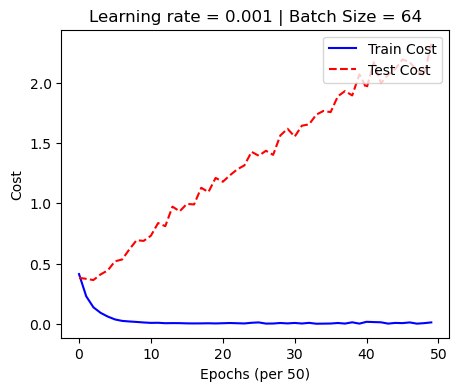

Accuracy: 99.98%
Accuracy: 87.07%
Result -> Train Error: 0.02% | Test Error: 12.93%

Training model with n_h = 3000...


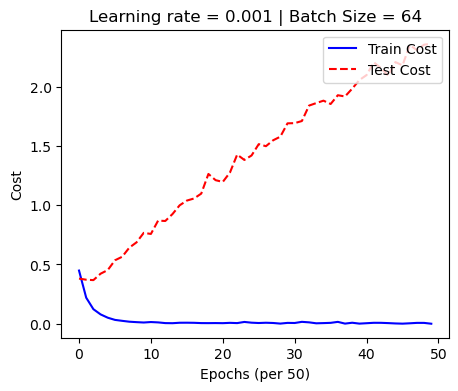

Accuracy: 99.83%
Accuracy: 86.37%
Result -> Train Error: 0.17% | Test Error: 13.63%

Training model with n_h = 3500...


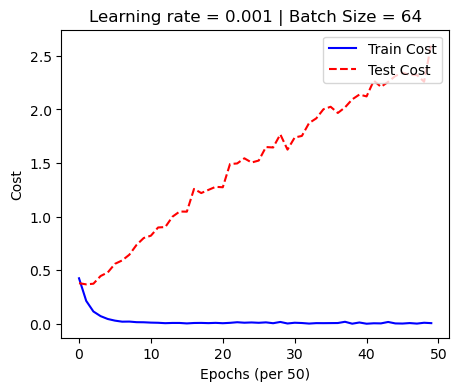

Accuracy: 99.46%
Accuracy: 85.84%
Result -> Train Error: 0.54% | Test Error: 14.16%

Training model with n_h = 4000...


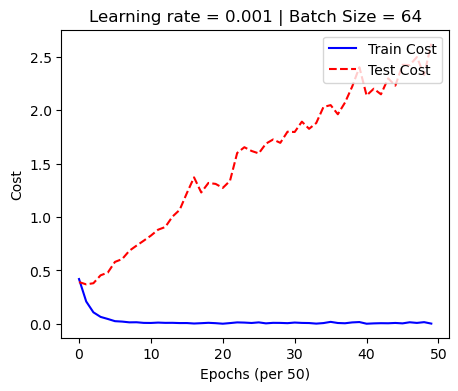

Accuracy: 99.98%
Accuracy: 87.22%
Result -> Train Error: 0.02% | Test Error: 12.78%

Training model with n_h = 4500...


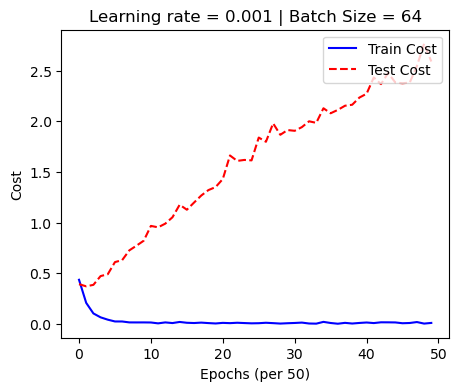

Accuracy: 99.92%
Accuracy: 86.37%
Result -> Train Error: 0.08% | Test Error: 13.63%

Training model with n_h = 5000...


C:\Users\Piyansh shukla\AppData\Local\Temp\ipykernel_27952\1239269924.py:5: RuntimeWarning: overflow encountered in exp
  A = 1/(1+np.exp(-Z))
C:\Users\Piyansh shukla\AppData\Local\Temp\ipykernel_27952\1239269924.py:35: RuntimeWarning: overflow encountered in exp
  s = 1/(1+np.exp(-Z))


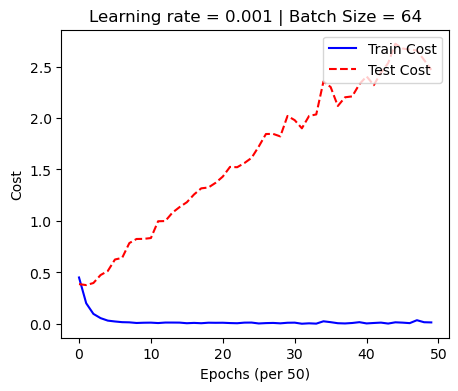

Accuracy: 99.13%
Accuracy: 87.45%
Result -> Train Error: 0.87% | Test Error: 12.55%

Training model with n_h = 5500...


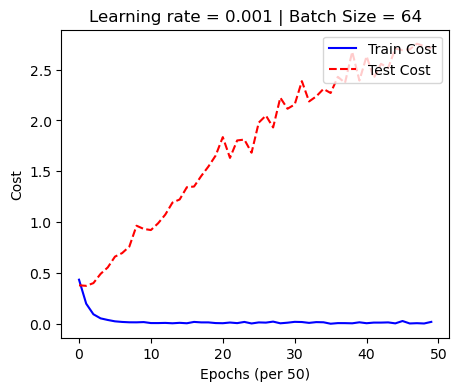

Accuracy: 99.77%
Accuracy: 85.76%
Result -> Train Error: 0.23% | Test Error: 14.24%

Training model with n_h = 6000...


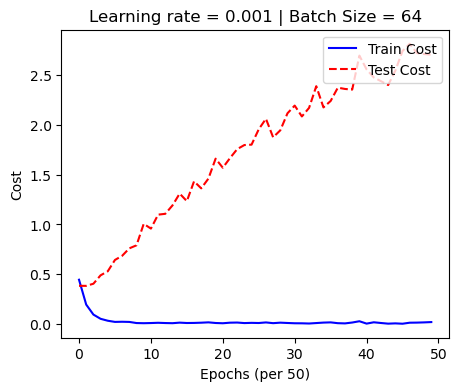

Accuracy: 99.98%
Accuracy: 86.91%
Result -> Train Error: 0.02% | Test Error: 13.09%

Training model with n_h = 6500...


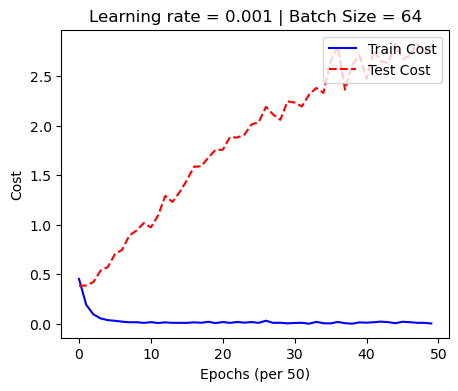

Accuracy: 99.87%
Accuracy: 85.60%
Result -> Train Error: 0.13% | Test Error: 14.40%



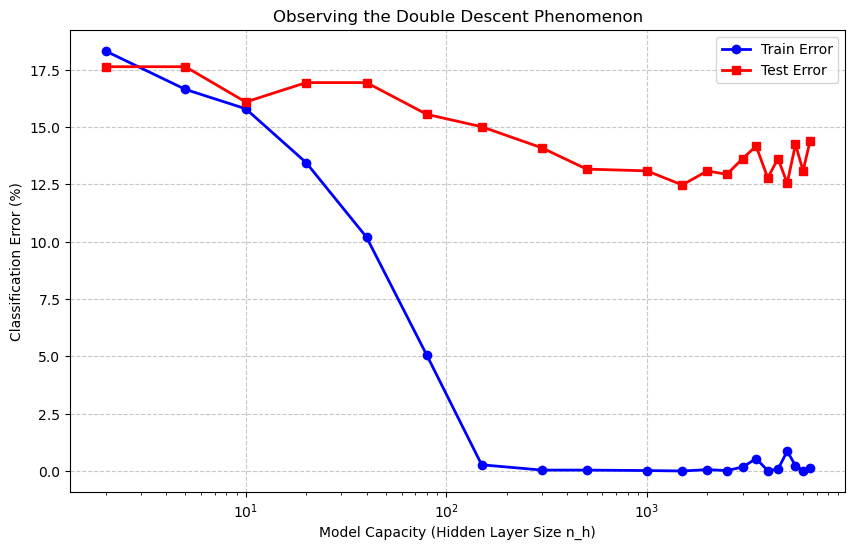

In [45]:
# 1. Define a range of model capacities (hidden layer sizes)
# We move from highly under-parameterized to massively over-parameterized
hidden_sizes = [2, 5, 10, 20, 40, 80, 150, 300, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500]

train_errors = []
test_errors = []

for n_h in hidden_sizes:
    print(f"Training model with n_h = {n_h}...")
    
    # 2. Train the model 
    params = model(
        X_train=X_train_np, 
        Y_train=Y_train_2D, 
        X_test=X_test_np, 
        Y_test=Y_test_2D, 
        layers_dims=(n_x, n_h, n_y), 
        learning_rate=0.001,  
        num_epochs=2500,     
        mini_batch_size=64,
        print_cost=False  
    )
    
    # 3. Get predictions
    train_preds = predict(X_train_np, Y_train_2D, params)
    test_preds = predict(X_test_np, Y_test_2D, params)
    
    # 4. Calculate ERROR (100% - Accuracy%)
    train_err = 100 - (np.mean(train_preds == Y_train_2D) * 100)
    test_err = 100 - (np.mean(test_preds == Y_test_2D) * 100)
    
    train_errors.append(train_err)
    test_errors.append(test_err)
    
    print(f"Result -> Train Error: {train_err:.2f}% | Test Error: {test_err:.2f}%\n")


# 5. Plot the Double Descent Curve!
plt.figure(figsize=(10, 6))
plt.plot(hidden_sizes, train_errors, label='Train Error', color='blue', marker='o', linewidth=2)
plt.plot(hidden_sizes, test_errors, label='Test Error', color='red', marker='s', linewidth=2)

# Use a log scale for the X-axis because we jump from 2 to 6500
plt.xscale('log') 
plt.xlabel('Model Capacity (Hidden Layer Size n_h)')
plt.ylabel('Classification Error (%)')
plt.title('Observing the Double Descent Phenomenon')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

tho training almost hit a plateau but the test error didn't increase much at all. i think it requires 10^5-10^6 hiddne units to show double descent 

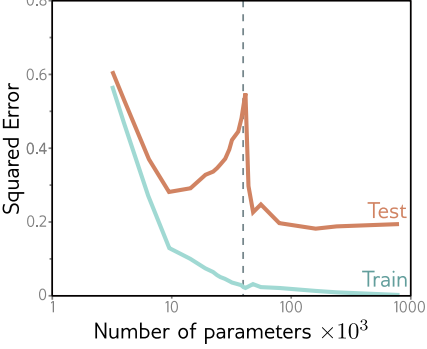 <br>

i was hoping to get something like this 